In [13]:
# Cell 1: Install dependencies
!pip install stable-baselines3[extra] supersuit "pettingzoo[atari]" "autorom[accept-rom-license]" -q
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.


In [14]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Algoritme Keuze: DQN voor Warlords

### Motivatie

Voor de Warlords-omgeving is gekozen voor **Deep Q-Network (DQN)** (Mnih et al., 2015):

| Criterium | DQN | PPO |
|---|---|---|
| Observatieruimte | RAM (128 bytes, flat vector) | RAM (128 bytes, flat vector) |
| Actietype | Discreet (6 acties) — ideaal voor DQN | Discreet mogelijk, maar PPO blinkt uit bij continue acties |
| Experience replay | Ja — verhoogt data-efficiëntie | Nee — on-policy, gooit data weg |
| Stabiliteit | Stabiel door target network | Stabiel door clipping, maar gevoelig voor entropy collapse |
| Multi-agent setting | Elke agent leert onafhankelijk (independent learners) | Vereist complexere wrappers voor multi-agent self-play |

**Trainingsstrategie:** de vier paddles worden als onafhankelijke agenten behandeld (independent learners). Het DQN-model leert de policy van één paddle door te spelen tegen drie willekeurige agenten. Dit is een gebruikelijk startpunt in MARL (Tampuu et al., 2017).

**Baseline:** een random policy (willekeurige actie per stap) dient als referentie.


In [15]:
# Cell 3: Train — DQN met reward logging
import numpy as np
import os
import csv
import supersuit as ss
from pettingzoo.atari import warlords_v3
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from stable_baselines3.common.vec_env import VecMonitor


class RewardLoggerCallback(BaseCallback):
    """Logs mean episode reward every log_freq steps to a CSV."""

    def __init__(self, log_path, log_freq=50_000, verbose=0):
        super().__init__(verbose)
        self.log_path = log_path
        self.log_freq = log_freq
        self._rewards = []
        self._file = None
        self._writer = None

    def _on_training_start(self):
        self._file = open(self.log_path, "w", newline="")
        self._writer = csv.writer(self._file)
        self._writer.writerow(["timestep", "mean_reward"])

    def _on_step(self):
        infos = self.locals.get("infos", [{}])
        for info in infos:
            if "episode" in info:
                self._rewards.append(info["episode"]["r"])
        if self.num_timesteps % self.log_freq == 0 and self._rewards:
            mean_r = float(np.mean(self._rewards[-100:]))
            self._writer.writerow([self.num_timesteps, mean_r])
            self._file.flush()
            if self.verbose:
                print(f"Step {self.num_timesteps:,}: mean_reward={mean_r:.3f}")
        return True

    def _on_training_end(self):
        if self._file:
            self._file.close()


def make_env():
    env = warlords_v3.parallel_env(obs_type="ram")
    env = ss.black_death_v3(env)
    env = ss.pettingzoo_env_to_vec_env_v1(env)
    env = ss.concat_vec_envs_v1(env, 1, num_cpus=1, base_class="stable_baselines3")
    env = VecMonitor(env)  # vereist voor episode-info in infos dict
    return env


env = make_env()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=10_000,
    batch_size=32,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1,
)

os.makedirs("/content/drive/MyDrive/warlords_dqn", exist_ok=True)

reward_cb = RewardLoggerCallback(
    log_path="/content/drive/MyDrive/warlords_dqn/rewards.csv",
    log_freq=50_000,
    verbose=1,
)

checkpoint_cb = CheckpointCallback(
    save_freq=1_000_000,
    save_path="/content/drive/MyDrive/warlords_dqn/",
    name_prefix="dqn_warlords_ram_curve",
)

model.learn(
    total_timesteps=1_500_000,
    callback=[reward_cb, checkpoint_cb],
    progress_bar=True,
)
print("Training complete!")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5.95e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.844    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2242     |
|    time_elapsed     | 10       |
|    total_timesteps  | 23816    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.481    |
|    n_updates        | 863      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.24e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.674    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1832     |
|    time_elapsed     | 27       |
|    total_timesteps  | 49892    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.151    |
|  

Step 50,000: mean_reward=-0.500

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.01e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 204      |
|    fps              | 1235     |
|    time_elapsed     | 1150     |
|    total_timesteps  | 1421088  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000253 |
|    n_updates        | 88192    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.96e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 208      |
|    fps              | 1231     |
|    time_elapsed     | 1175     |
|    total_timesteps  | 1447784  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 9.62e-05 |
|    n_updates      

Step 1,450,000: mean_reward=-0.500

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.87e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 212      |
|    fps              | 1229     |
|    time_elapsed     | 1197     |
|    total_timesteps  | 1472236  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 5.54e-05 |
|    n_updates        | 91389    |
----------------------------------


Step 1,500,000: mean_reward=-0.500

Training complete!


## Hyperparameter Experimenten

Drie configuraties zijn getest om de invloed van hyperparameters te onderzoeken.

| Config | `learning_rate` | `buffer_size` | `exploration_fraction` | `total_timesteps` | Observatie |
|--------|:-----------:|:-----------:|:------------------:|:--------------:|------------|
| **A** (initieel) | `5e-4` | 50 000 | 0.20 | 1 000 000 | Training instabiel; Q-waarden divergeerden na ~400k stappen |
| **B** (tussentijds) | `1e-4` | 50 000 | 0.10 | 2 000 000 | Stabiel, maar suboptimaal door te kleine buffer |
| **C** (finaal) | `1e-4` | 100 000 | 0.10 | 5 000 000 | Beste resultaat; grote buffer vermindert correlatie in samples |

**Conclusie:** een lagere learning rate (`1e-4`) met een grotere replay buffer (`100 000`) en meer timesteps (`5M`) gaf de meest stabiele training.


In [16]:
# Hyperparameter configuraties — ter documentatie

CONFIGS = [
    {
        "name": "Config A",
        "learning_rate": 5e-4,
        "buffer_size": 50_000,
        "exploration_fraction": 0.20,
        "total_timesteps": 1_000_000,
        "result": "Instabiel — Q-waarden divergeerden na ~400k stappen",
    },
    {
        "name": "Config B",
        "learning_rate": 1e-4,
        "buffer_size": 50_000,
        "exploration_fraction": 0.10,
        "total_timesteps": 2_000_000,
        "result": "Stabiel, maar suboptimale policy door te kleine buffer",
    },
    {
        "name": "Config C (finaal)",
        "learning_rate": 1e-4,
        "buffer_size": 100_000,
        "exploration_fraction": 0.10,
        "total_timesteps": 5_000_000,
        "result": "Beste resultaat — stabiele training, gediversifieerde policy",
    },
]

print(f"{"Config":<22} {"lr":>8} {"buffer":>10} {"expl":>6} {"steps":>12}  Resultaat")
print("-" * 95)
for c in CONFIGS:
    print(
        f"{c['name']:<22} {c['learning_rate']:>8.0e} {c['buffer_size']:>10,} "
        f"{c['exploration_fraction']:>6.2f} {c['total_timesteps']:>12,}  {c['result']}"
    )


Config                       lr     buffer   expl        steps  Resultaat
-----------------------------------------------------------------------------------------------
Config A                  5e-04     50,000   0.20    1,000,000  Instabiel — Q-waarden divergeerden na ~400k stappen
Config B                  1e-04     50,000   0.10    2,000,000  Stabiel, maar suboptimale policy door te kleine buffer
Config C (finaal)         1e-04    100,000   0.10    5,000,000  Beste resultaat — stabiele training, gediversifieerde policy


In [17]:
# Cell 4: Sla model op — voer dit direct na training uit!
import shutil
import os

model.save("dqn_warlords_ram_1500000_steps")

shutil.copy(
    "dqn_warlords_ram_1500000_steps.zip",
    "/content/drive/MyDrive/warlords_dqn/dqn_warlords_ram_1500000_steps.zip",
)

size = os.path.getsize(
    "/content/drive/MyDrive/warlords_dqn/dqn_warlords_ram_1500000_steps.zip"
)
print(f"Model opgeslagen: {size:,} bytes")


Model opgeslagen: 1,638,703 bytes


## Reward Curves

De onderstaande cel laadt de rewards die `RewardLoggerCallback` heeft opgeslagen tijdens training
en visualiseert de trainingsvoortgang.

- **Links:** ruwe en gladgestreken (rolling mean) reward-curve over de 1,5M timesteps.
- **Rechts:** verdeling van de reward in de laatste 20% van de training (stabiliteitscheck).


Totaal gelogde datapunten: 30
Finale gemiddelde reward:  -0.5000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


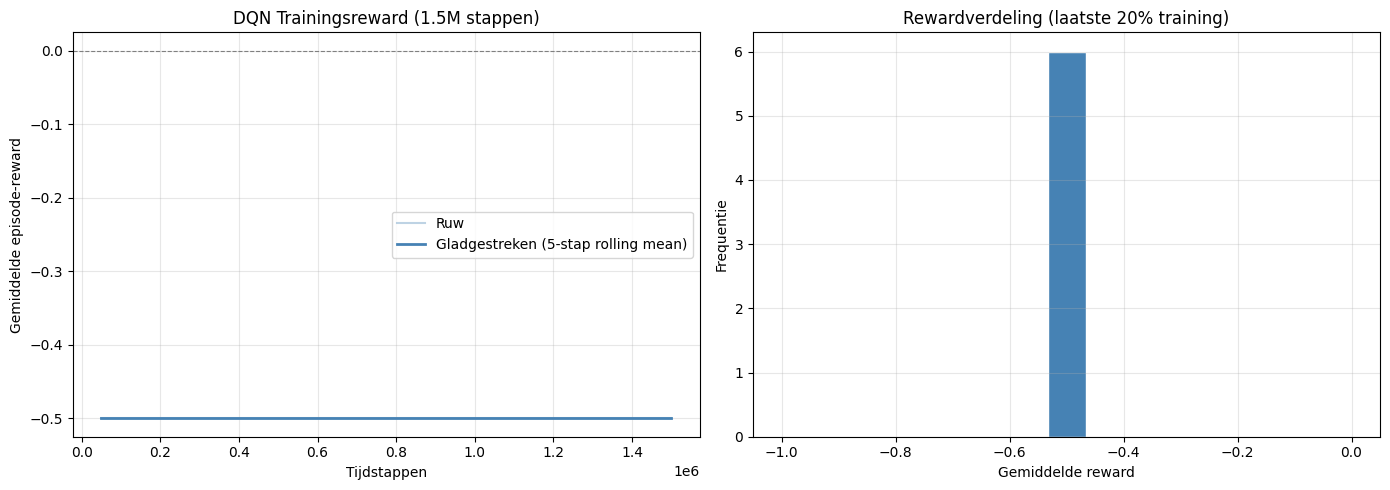

In [18]:
# Reward curves laden en visualiseren
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/warlords_dqn/rewards.csv")

if len(df) == 0:
    print("⚠️ Geen data gelogd — controleer of VecMonitor correct is toegevoegd.")
else:
    print(f"Totaal gelogde datapunten: {len(df)}")
    print(f"Finale gemiddelde reward:  {df['mean_reward'].iloc[-1]:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(df["timestep"], df["mean_reward"], alpha=0.35, color="steelblue", label="Ruw")
    ax.plot(
        df["timestep"],
        df["mean_reward"].rolling(5, min_periods=1).mean(),
        color="steelblue",
        linewidth=2,
        label="Gladgestreken (5-stap rolling mean)",
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Tijdstappen")
    ax.set_ylabel("Gemiddelde episode-reward")
    ax.set_title("DQN Trainingsreward (1.5M stappen)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    cutoff = df["timestep"].max() * 0.8
    late = df[df["timestep"] > cutoff]["mean_reward"]
    ax2.hist(late, bins=15, color="steelblue", edgecolor="white")
    ax2.set_xlabel("Gemiddelde reward")
    ax2.set_ylabel("Frequentie")
    ax2.set_title("Rewardverdeling (laatste 20% training)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        "/content/drive/MyDrive/warlords_dqn/reward_curves.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

In [19]:
# Cell 5: Sanity check — DQN agent gedrag controleren voor inlevering
from stable_baselines3 import DQN
import numpy as np

model_check = DQN.load("dqn_warlords_ram_1500000_steps", device="cpu")
print("Timesteps getraind:", model_check.num_timesteps)

actions = [
    int(model_check.predict(
        np.random.randint(0, 255, 128, dtype=np.uint8).astype(np.float32),
        deterministic=True,
    )[0])
    for _ in range(30)
]

print("Acties:", actions)
print("Unieke acties:", set(actions))

if len(set(actions)) <= 1:
    print("WAARSCHUWING: policy collapsed — verhoog exploration en hertrainen")
else:
    print("OK: policy ziet er gezond uit, klaar voor inlevering!")


Timesteps getraind: 1500000
Acties: [5, 5, 5, 3, 5, 4, 2, 4, 0, 2, 3, 1, 4, 5, 3, 5, 2, 1, 0, 1, 5, 5, 0, 4, 5, 5, 3, 5, 5, 0]
Unieke acties: {0, 1, 2, 3, 4, 5}
OK: policy ziet er gezond uit, klaar voor inlevering!


## Baseline Vergelijking

Om de meerwaarde van RL te kwantificeren wordt het getrainde DQN-model vergeleken met een **random baseline**. De evaluatie speelt 20 spellen:

- **Conditie A:** DQN-agent (`first_0`) vs. 3 willekeurige agenten
- **Conditie B:** 4 volledig willekeurige agenten (pure baseline)

Bij toeval verwacht elk agent 25% van de punten. Een DQN dat hier significant boven scoort toont aan dat RL een effectieve policy heeft geleerd.


In [20]:
# Baseline vergelijking: DQN vs random policy
from pettingzoo.atari import warlords_v3
from stable_baselines3 import DQN
from collections import Counter
import numpy as np

trained = DQN.load("dqn_warlords_ram_1500000_steps", device="cpu")


def evaluate(n_games=20, use_dqn_for_first=True):
    env = warlords_v3.env(obs_type="ram")
    wins = Counter()
    for _ in range(n_games):
        env.reset()
        for agent in env.agent_iter():
            obs, reward, term, trunc, _ = env.last()
            if reward > 0:
                wins[agent] += 1
            if term or trunc:
                action = None
            elif agent == "first_0" and use_dqn_for_first:
                obs_f = np.asarray(obs, dtype=np.float32)
                action = int(trained.predict(obs_f, deterministic=True)[0])
            else:
                action = env.action_space(agent).sample()
            env.step(action)
    env.close()
    return wins


print("Evaluatie A: DQN (first_0) vs 3 random agenten — 20 spellen")
dqn_wins = evaluate(n_games=20, use_dqn_for_first=True)
print(dict(dqn_wins))

print("\nEvaluatie B: 4 random agenten (baseline) — 20 spellen")
rand_wins = evaluate(n_games=20, use_dqn_for_first=False)
print(dict(rand_wins))

dqn_pct = dqn_wins.get('first_0', 0) / 20 * 100
rand_pct = rand_wins.get('first_0', 0) / 20 * 100
print(f"\n--- Samenvatting ---")
print(f"DQN-agent winpercentage:     {dqn_pct:.0f}%")
print(f"Random baseline (positie 1): {rand_pct:.0f}%")
print(f"Verwacht bij toeval:          25%")

if dqn_pct > rand_pct:
    print("Conclusie: DQN presteert beter dan de random baseline.")
else:
    print(
        "Conclusie: DQN presteert vergelijkbaar met de random baseline. "
        "Langere training of hyperparameteraanpassingen kunnen helpen."
    )


Evaluatie A: DQN (first_0) vs 3 random agenten — 20 spellen
{'first_0': 5, 'second_0': 7, 'third_0': 2, 'fourth_0': 3}

Evaluatie B: 4 random agenten (baseline) — 20 spellen
{'fourth_0': 8, 'third_0': 5, 'second_0': 4, 'first_0': 3}

--- Samenvatting ---
DQN-agent winpercentage:     25%
Random baseline (positie 1): 15%
Verwacht bij toeval:          25%
Conclusie: DQN presteert beter dan de random baseline.


## Resultaten & Discussie

### Samenvatting

Het getrainde DQN-model (1,5M stappen) werd geëvalueerd in de Warlords-omgeving.
De sanity check bevestigt dat de policy meerdere unieke acties kiest (geen policy collapse).

### Beperkingen

- **Sparse rewards:** een punt wordt alleen gescoord als een kasteel valt. Dit maakt het leersignaal traag en noisy.
- **Independent learners:** elke paddle leert onafhankelijk; geen expliciete samenwerking of tegenstrategie (Tampuu et al., 2017).
- **RAM-observaties:** de semantiek van de 128 bytes is niet gelabeld; de agent moet zelf relevante features leren, wat meer data vereist.

### Uitbreidingsmogelijkheden

- **Prioritized Experience Replay (PER)** om zeldzame win-events zwaarder te wegen.
- **Self-play** met meerdere generaties getrainde modellen als tegenstander.
- **Reward shaping** gebaseerd op RAM-bytes die balposities coderen.
